**Practical No. 2**

Smart Emergency Ambulance Dispatch and Routing System for Pune using BFS, DFS, DLS, IDDFS, A\*, Hill Climbing, Genetic Algorithm and CSP

Name: Parth Nandkishor Shingane

Division: A

Batch: A2

PRN: 202401040210

Roll No: 51

GitHub Link: https://github.com/Parth-Shingane-27/AIML_Practicals

## Aim

To model an ambulance dispatch problem for Pune and solve its parts with BFS, DFS, DLS, IDDFS, A\*, Hill Climbing, a Genetic Algorithm and a Constraint Satisfaction Problem (CSP), then compare the results in kilometres.

## Objectives

1. Represent Pune's roads as a weighted graph with localities as nodes and distances in km as edge weights.
2. Find routes from the hospital to each locality using BFS, DFS, DLS and IDDFS.
3. Find the same routes with A\* using a straight-line heuristic.
4. Order the patients of one area, and of the whole city, using Hill Climbing and a Genetic Algorithm.
5. Assign ambulances to emergency calls as a CSP and solve it with backtracking.
6. Compare what each method gives in kilometres.

## Flowcharts

Each flowchart shows how one algorithm works in this notebook. Blue boxes are steps, yellow diamonds are decisions and red boxes are where a decision ends the search.

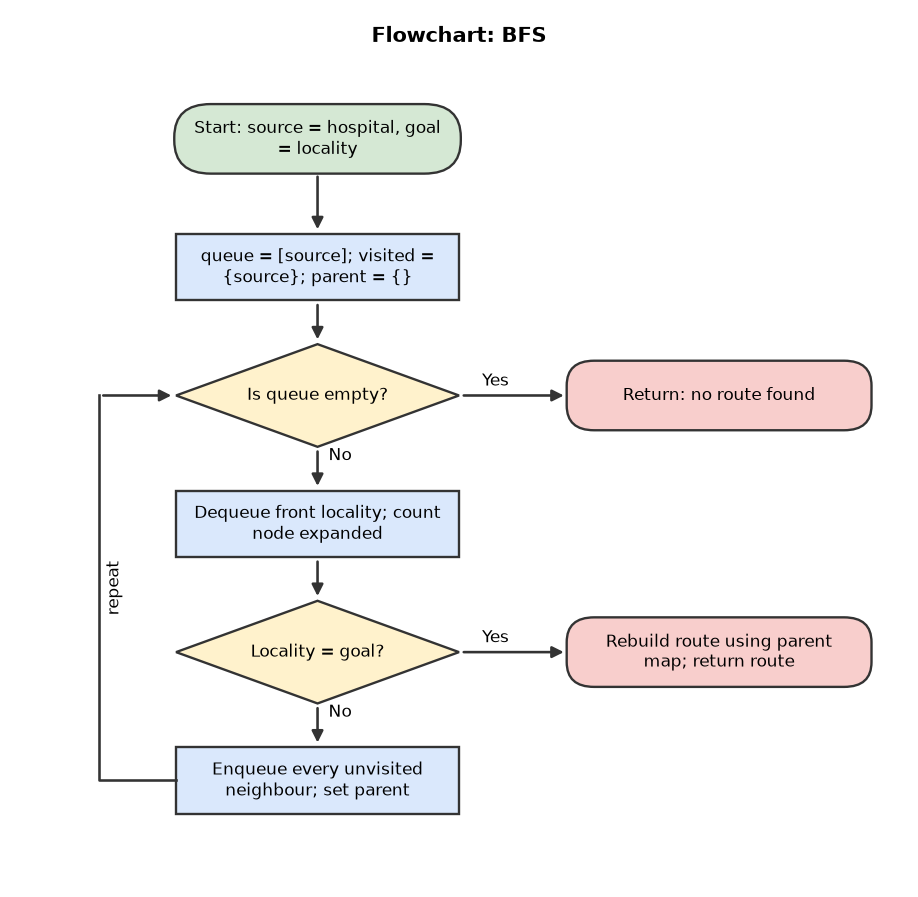

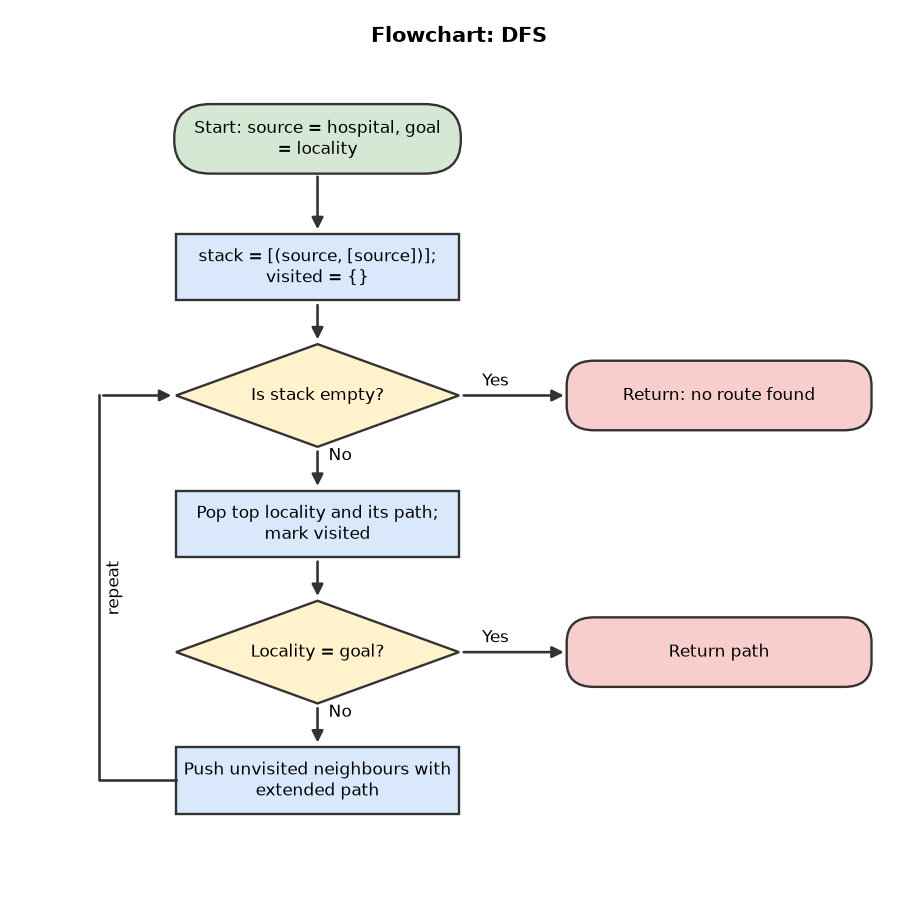

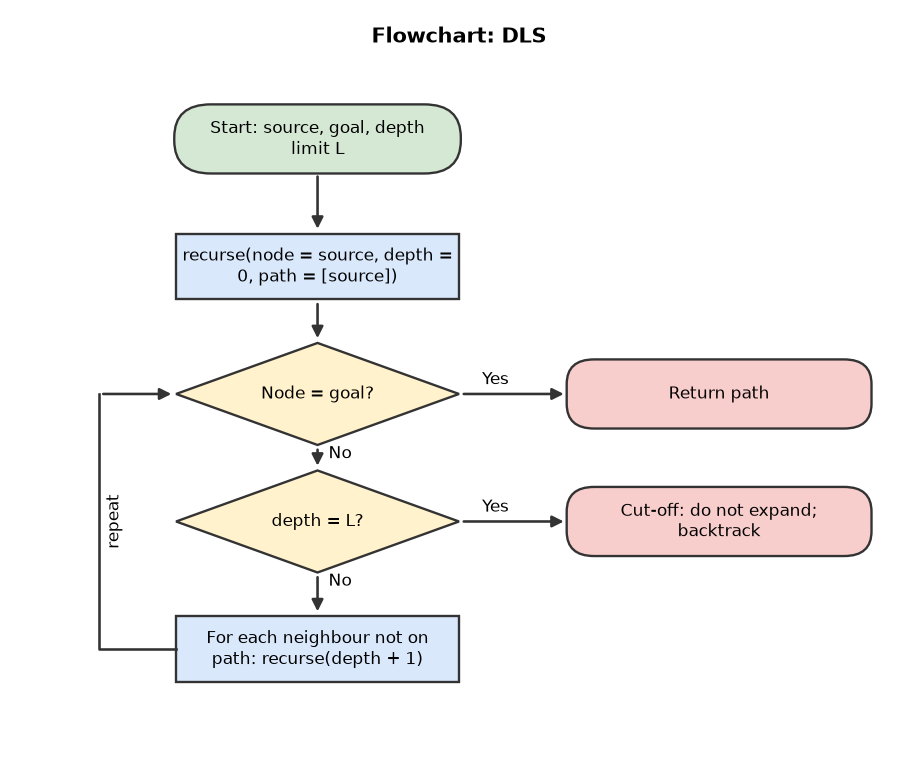

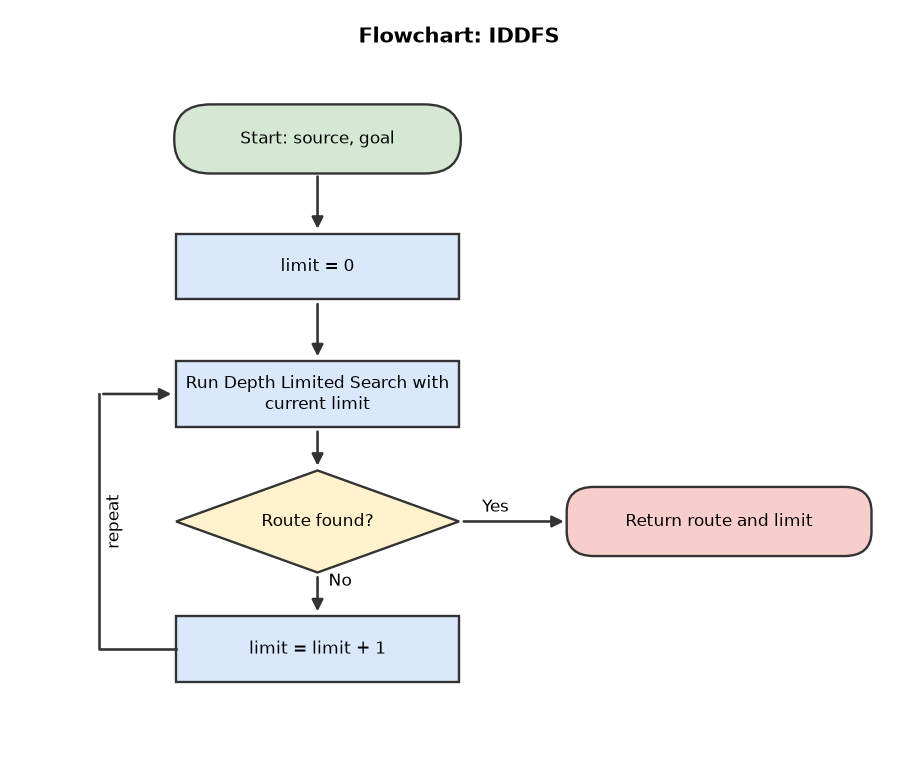

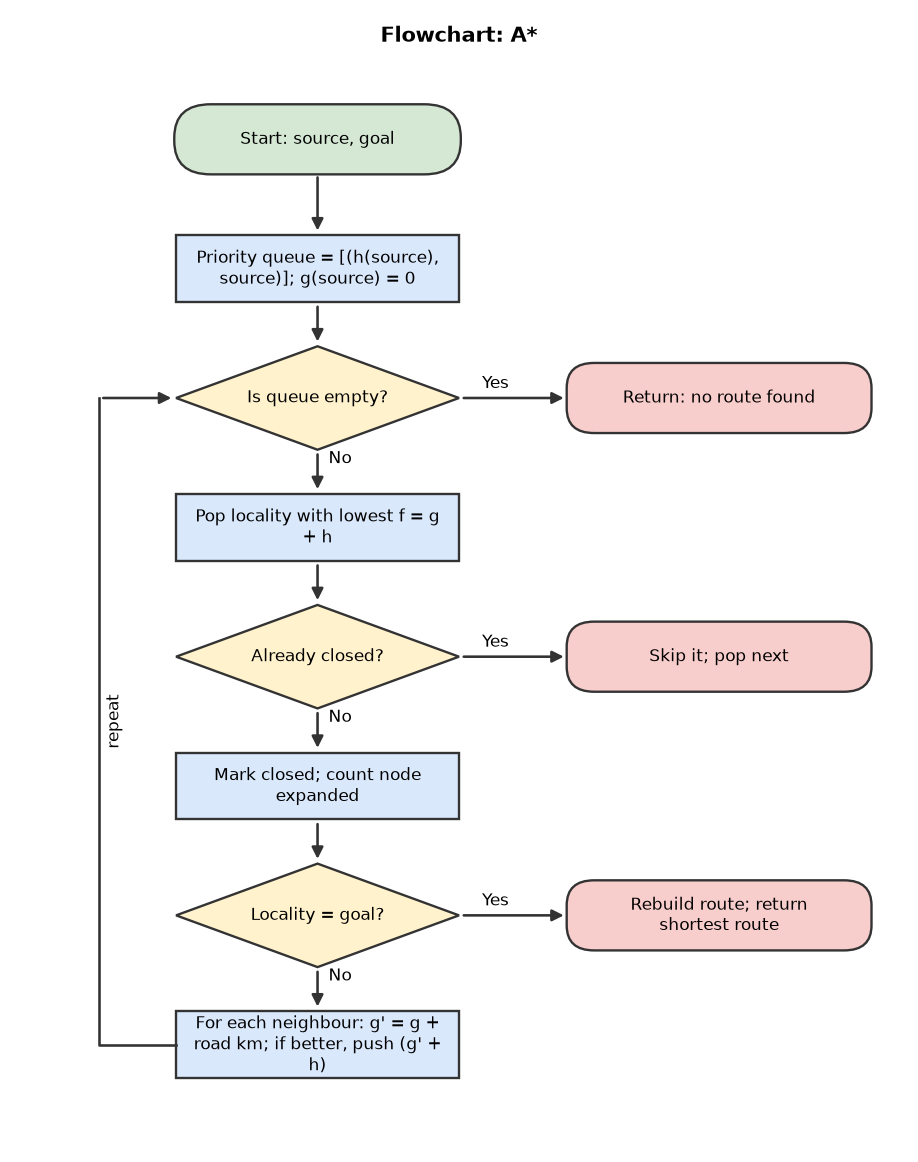

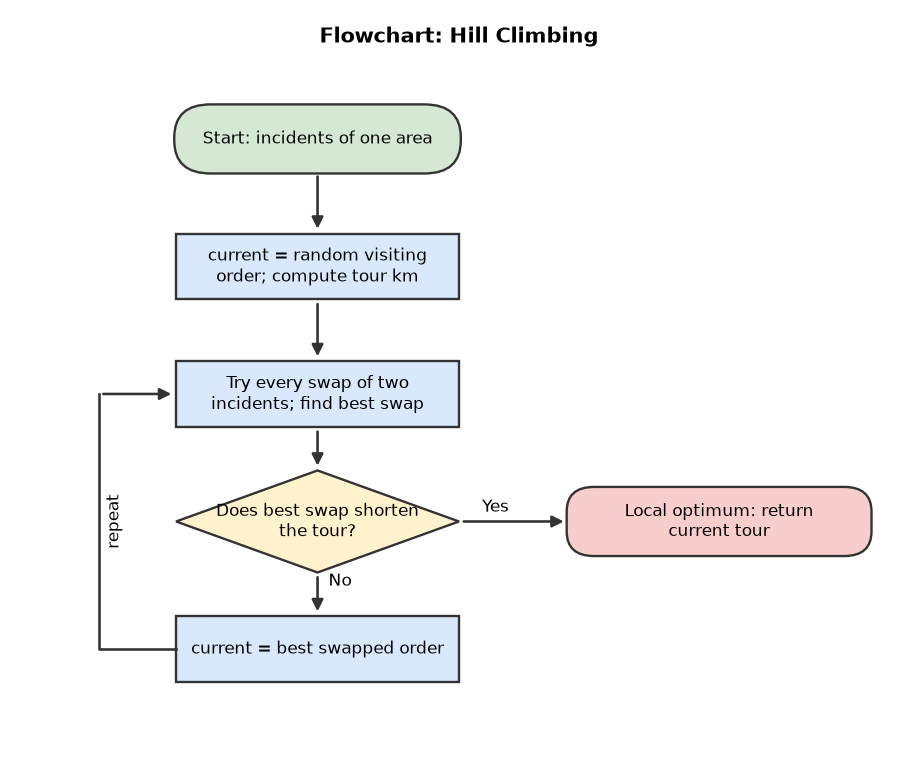

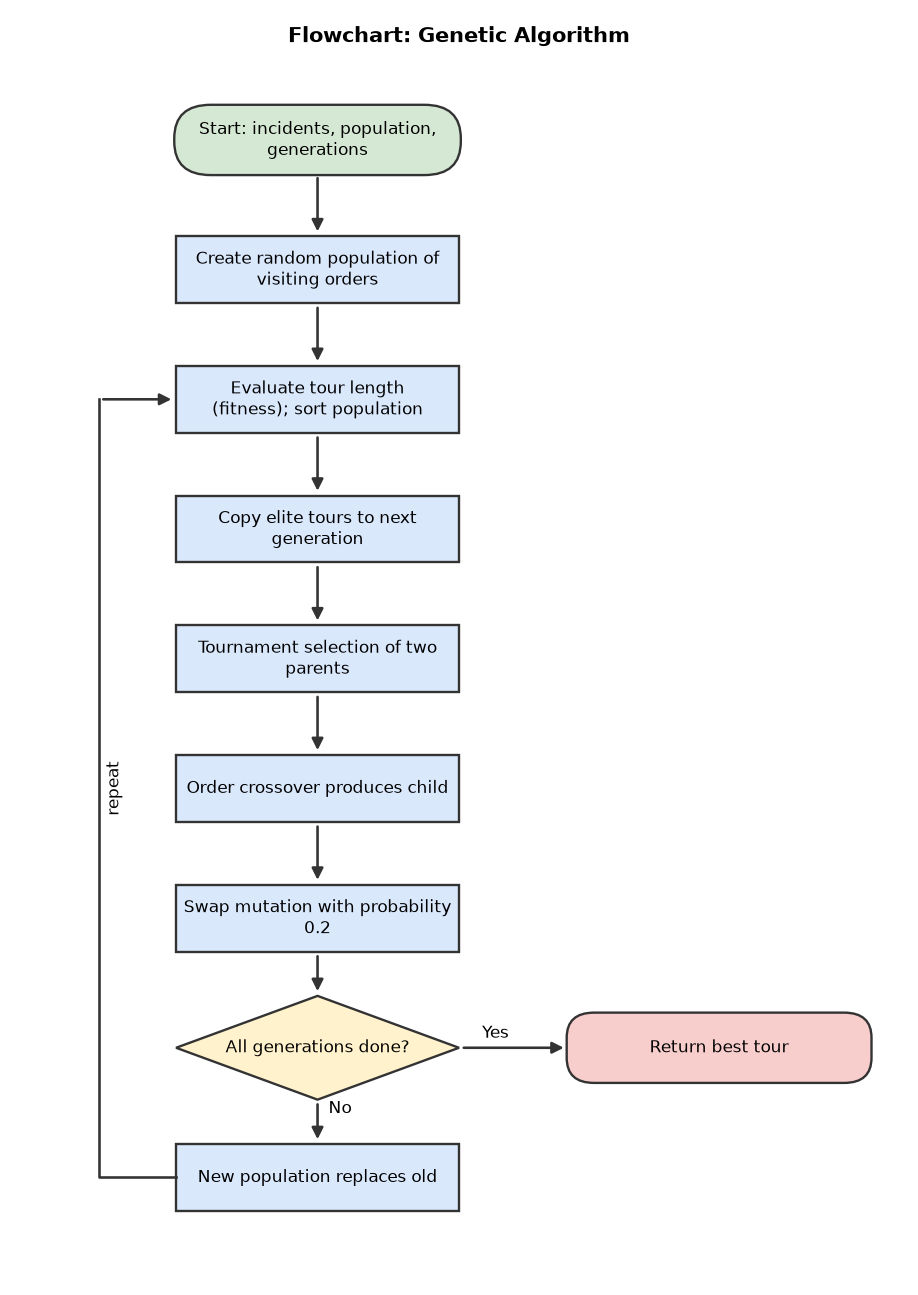

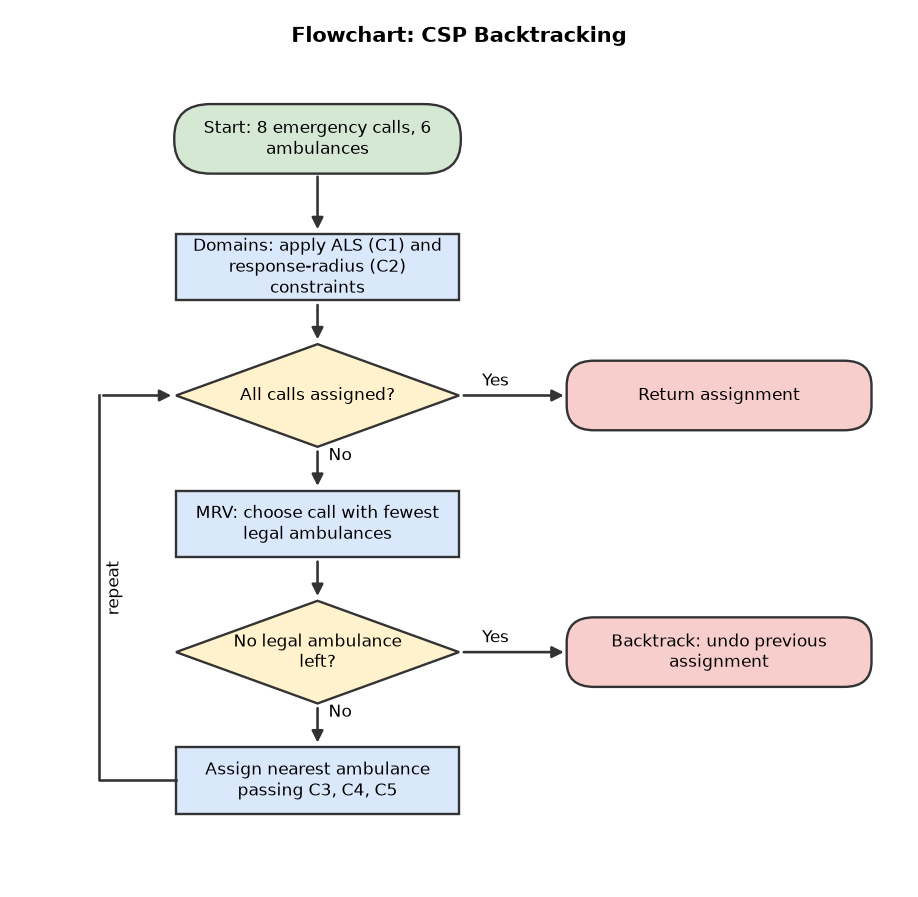

## Graph Representation

The road network is a weighted undirected graph. Each locality is a node and each road is an edge whose weight is the road distance in km. Shivajinagar Central Hospital is the starting point of every search. The road distances are approximate values taken for this exercise, and the latitude and longitude are approximate centres of the localities.

A state is the locality the ambulance is in, so there are 12 states. The goal state is the locality of the emergency, an action is driving along one road, and the cost of an action is the length of that road.

In [1]:
import heapq
import math
import random
from collections import deque
from itertools import permutations
import networkx as nx
import matplotlib.pyplot as plt


HOSPITAL = "Shivajinagar"


roads = [
    ("Shivajinagar", "Deccan", 3), ("Shivajinagar", "Kothrud", 6),
    ("Shivajinagar", "Baner", 8), ("Shivajinagar", "Viman Nagar", 9),
    ("Shivajinagar", "Pimpri", 14),
    ("Deccan", "Swargate", 5), ("Deccan", "Kothrud", 4),
    ("Kothrud", "Baner", 7), ("Kothrud", "Swargate", 7),
    ("Baner", "Wakad", 6), ("Baner", "Hinjewadi", 9),
    ("Wakad", "Hinjewadi", 6), ("Wakad", "Pimpri", 7),
    ("Swargate", "Katraj", 7), ("Swargate", "Hadapsar", 10),
    ("Hadapsar", "Kharadi", 8), ("Hadapsar", "Viman Nagar", 9),
    ("Viman Nagar", "Kharadi", 5),
]

graph = {}
for a, b, w in roads:
    graph.setdefault(a, {})[b] = w
    graph.setdefault(b, {})[a] = w

state_space = list(graph)


def get_neighbors(city):
    """Successor function: localities reachable by one direct road."""
    return list(graph[city])


coordinates = {
    "Shivajinagar": (18.5308, 73.8475), "Deccan": (18.5167, 73.8416),
    "Kothrud": (18.5074, 73.8077), "Baner": (18.5590, 73.7868),
    "Wakad": (18.5975, 73.7898), "Hinjewadi": (18.5913, 73.7389),
    "Pimpri": (18.6298, 73.7997), "Swargate": (18.5018, 73.8636),
    "Katraj": (18.4575, 73.8677), "Hadapsar": (18.5089, 73.9260),
    "Viman Nagar": (18.5679, 73.9143), "Kharadi": (18.5511, 73.9406),
}

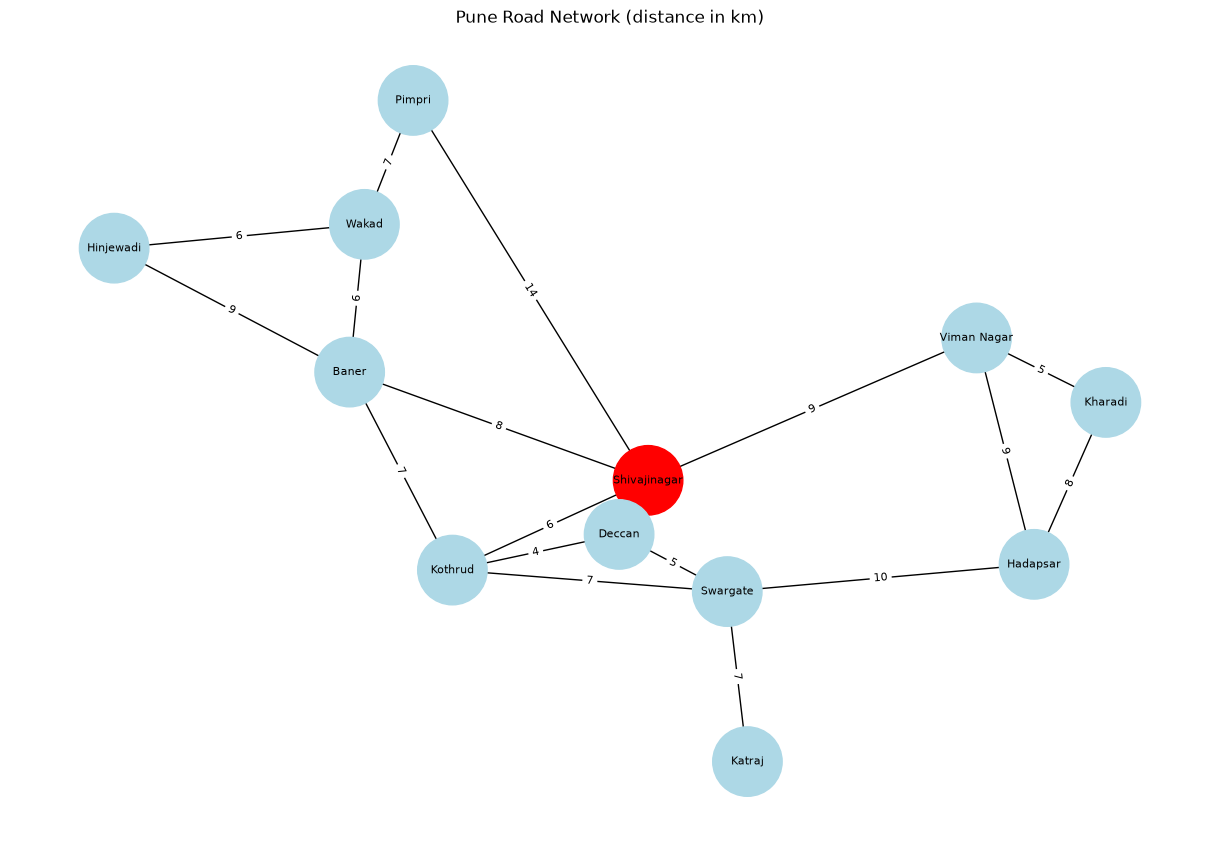

In [2]:
G = nx.Graph()
for a, b, w in roads:
    G.add_edge(a, b, weight=w)

pos = {c: (lon, lat) for c, (lat, lon) in coordinates.items()}
colours = ["red" if n == HOSPITAL else "lightblue" for n in G.nodes]

plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_color=colours, node_size=2500, font_size=8)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "weight"), font_size=8)
plt.title("Pune Road Network (distance in km)")
plt.show()

## Emergency Incidents

There are 28 emergency incidents (E001 to E028) spread over the localities. A fixed random seed is used so every run gives the same incidents. Each has a locality, a severity and a position in km from the locality centre.

In [3]:
def build_incidents():
    rng = random.Random(2026)
    per_locality = {"Kothrud": 6, "Hadapsar": 5, "Pimpri": 4, "Hinjewadi": 4,
                    "Swargate": 2, "Baner": 2, "Deccan": 1, "Kharadi": 1,
                    "Viman Nagar": 1, "Wakad": 1, "Katraj": 1}
    severities = ["Critical", "Serious", "Minor"]
    incidents, n = {}, 1
    for loc, count in per_locality.items():
        for _ in range(count):
            incidents[f"E{n:03d}"] = {
                "locality": loc,
                "patient": f"Patient {n}",
                "severity": rng.choice(severities),
                # position (km) relative to the locality centre
                "xy": (round(rng.uniform(-3, 3), 1), round(rng.uniform(-3, 3), 1)),
            }
            n += 1
    return incidents

incidents = build_incidents()

def incidents_in(locality):
    return [i for i, d in incidents.items() if d["locality"] == locality]

for i, d in incidents.items():
    print(i, d["locality"], d["severity"], d["xy"])

E001 Kothrud Critical (-1.1, 2.7)
E002 Kothrud Minor (2.2, -2.4)
E003 Kothrud Critical (2.4, 0.7)
E004 Kothrud Serious (1.7, 0.3)
E005 Kothrud Minor (1.7, -0.1)
E006 Kothrud Minor (-0.4, -3.0)
E007 Hadapsar Critical (-2.3, 1.9)
E008 Hadapsar Serious (-2.9, 2.3)
E009 Hadapsar Serious (1.1, -1.7)
E010 Hadapsar Serious (-0.9, 3.0)
E011 Hadapsar Serious (1.8, 3.0)
E012 Pimpri Minor (0.8, 1.3)
E013 Pimpri Critical (0.3, -1.2)
E014 Pimpri Serious (-2.2, 0.9)
E015 Pimpri Minor (0.5, -2.9)
E016 Hinjewadi Minor (-0.8, -0.2)
E017 Hinjewadi Critical (-0.6, 0.5)
E018 Hinjewadi Serious (2.2, -0.4)
E019 Hinjewadi Minor (2.3, -0.6)
E020 Swargate Minor (-1.4, -0.5)
E021 Swargate Serious (0.1, 1.8)
E022 Baner Minor (-1.7, -2.2)
E023 Baner Critical (2.8, 0.1)
E024 Deccan Minor (-2.4, 0.7)
E025 Kharadi Serious (-2.1, 2.3)
E026 Viman Nagar Critical (0.8, -0.3)
E027 Wakad Serious (1.3, 2.8)
E028 Katraj Minor (-1.5, -0.6)


## Breadth First Search (BFS)

BFS uses a queue and visits localities level by level, so it finds the route with the fewest roads. Fewest roads is not always fewest km.

In [4]:
def route_distance(route):
    return sum(graph[route[i]][route[i + 1]] for i in range(len(route) - 1))


def bfs(start, goal):
    queue, parent, expanded = deque([start]), {start: None}, 0
    while queue:
        cur = queue.popleft()
        expanded += 1
        if cur == goal:
            return _path(parent, goal), expanded
        for nxt in get_neighbors(cur):
            if nxt not in parent:
                parent[nxt] = cur
                queue.append(nxt)
    return None, expanded


def _path(parent, goal):
    route, cur = [], goal
    while cur is not None:
        route.append(cur)
        cur = parent[cur]
    return route[::-1]

route, _ = bfs(HOSPITAL, "Katraj")
print("BFS route to Katraj:", " -> ".join(route))
print("Distance:", route_distance(route), "km")

BFS route to Katraj: Shivajinagar -> Deccan -> Swargate -> Katraj
Distance: 15 km


## Depth First Search (DFS)

DFS uses a stack and follows one road as deep as possible before backtracking. It can return a long detour.

In [5]:
def dfs(start, goal):
    stack, visited, expanded = [(start, [start])], set(), 0
    while stack:
        cur, path = stack.pop()
        if cur in visited:
            continue
        visited.add(cur)
        expanded += 1
        if cur == goal:
            return path, expanded
        for nxt in reversed(get_neighbors(cur)):
            if nxt not in visited:
                stack.append((nxt, path + [nxt]))
    return None, expanded

route, _ = dfs(HOSPITAL, "Hinjewadi")
print("DFS route to Hinjewadi:", " -> ".join(route))
print("Distance:", route_distance(route), "km")

DFS route to Hinjewadi: Shivajinagar -> Deccan -> Swargate -> Kothrud -> Baner -> Wakad -> Hinjewadi
Distance: 34 km


## Depth Limited Search (DLS)

DLS is DFS with a depth limit L. It fails if the goal is deeper than L. Katraj is 3 roads from the hospital.

In [6]:
def dls(start, goal, limit):
    """Depth Limited Search. Returns (route | None, expanded, cutoff_hit)."""
    counter = {"n": 0, "cutoff": False}

    def recurse(node, path, depth):
        counter["n"] += 1
        if node == goal:
            return path
        if depth == limit:
            counter["cutoff"] = True
            return None
        for nxt in get_neighbors(node):
            if nxt not in path:              # avoid cycles on the current path
                found = recurse(nxt, path + [nxt], depth + 1)
                if found:
                    return found
        return None

    route = recurse(start, [start], 0)
    return route, counter["n"], counter["cutoff"]

for limit in (2, 3):
    route, _, _ = dls(HOSPITAL, "Katraj", limit)
    if route:
        print(f"Limit {limit}:", " -> ".join(route), f"({route_distance(route)} km)")
    else:
        print(f"Limit {limit}: no route found, limit too small")

Limit 2: no route found, limit too small
Limit 3: Shivajinagar -> Deccan -> Swargate -> Katraj (15 km)


## Iterative Deepening DFS (IDDFS)

IDDFS runs DLS again and again with limits 0, 1, 2 and so on, so no limit has to be chosen in advance.

In [7]:
def iddfs(start, goal):
    """Iterative Deepening DFS. Returns (route, total expanded, depth found)."""
    total = 0
    for limit in range(len(graph)):
        route, expanded, cutoff = dls(start, goal, limit)
        total += expanded
        if route:
            return route, total, limit
        if not cutoff:
            break
    return None, total, None

route, _, limit = iddfs(HOSPITAL, "Katraj")
print("IDDFS route to Katraj:", " -> ".join(route))
print("Distance:", route_distance(route), "km (found at limit", limit, ")")

IDDFS route to Katraj: Shivajinagar -> Deccan -> Swargate -> Katraj
Distance: 15 km (found at limit 3 )


## A\* Search

A\* picks the locality with the smallest f(n) = g(n) + h(n). Here g(n) is the road distance travelled so far and h(n) is the straight-line distance to the goal.

In [8]:
def haversine(city, goal):
    lat1, lon1 = map(math.radians, coordinates[city])
    lat2, lon2 = map(math.radians, coordinates[goal])
    a = (math.sin((lat2 - lat1) / 2) ** 2
         + math.cos(lat1) * math.cos(lat2) * math.sin((lon2 - lon1) / 2) ** 2)
    return 6371 * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


def a_star(start, goal):
    pq, parent, g = [(haversine(start, goal), start)], {start: None}, {start: 0}
    closed, expanded = set(), 0
    while pq:
        _, cur = heapq.heappop(pq)
        if cur in closed:
            continue
        closed.add(cur)
        expanded += 1
        if cur == goal:
            return _path(parent, goal), expanded
        for nxt, w in graph[cur].items():
            new_g = g[cur] + w
            if nxt not in g or new_g < g[nxt]:
                g[nxt], parent[nxt] = new_g, cur
                heapq.heappush(pq, (new_g + haversine(nxt, goal), nxt))
    return None, expanded


def dijkstra(start):
    """Shortest road distance from start to every locality (ground truth)."""
    dist, pq = {start: 0}, [(0, start)]
    while pq:
        d, cur = heapq.heappop(pq)
        if d > dist[cur]:
            continue
        for nxt, w in graph[cur].items():
            if d + w < dist.get(nxt, math.inf):
                dist[nxt] = d + w
                heapq.heappush(pq, (d + w, nxt))
    return dist

route, _ = a_star(HOSPITAL, "Hinjewadi")
print("A* route to Hinjewadi:", " -> ".join(route))
print("Distance:", route_distance(route), "km")

A* route to Hinjewadi: Shivajinagar -> Baner -> Hinjewadi
Distance: 17 km


## Comparison of Routes in km

The five route finders are run from the hospital to all 11 localities (DLS limit = 3). The distance of each route is compared.

In [9]:
def compare_all(goals, dls_limit=3):
    rows = []
    optimal = dijkstra(HOSPITAL)
    for goal in goals:
        for name, fn in [("BFS", lambda: bfs(HOSPITAL, goal)),
                         ("DFS", lambda: dfs(HOSPITAL, goal)),
                         ("DLS", lambda: dls(HOSPITAL, goal, dls_limit)[:2]),
                         ("IDDFS", lambda: iddfs(HOSPITAL, goal)[:2]),
                         ("A*", lambda: a_star(HOSPITAL, goal))]:
            route, expanded = fn()
            rows.append({
                "goal": goal, "algo": name, "route": route, "expanded": expanded,
                "km": route_distance(route) if route else None,
                "hops": len(route) - 1 if route else None,
                "optimal": bool(route) and route_distance(route) == optimal[goal],
            })
    return rows

goals = [c for c in graph if c != HOSPITAL]
rows = compare_all(goals)
algos = ["BFS", "DFS", "DLS", "IDDFS", "A*"]


def km(goal, algo):
    return next(r for r in rows if r["goal"] == goal and r["algo"] == algo)["km"]


print("Distance in km from Shivajinagar Hospital to each locality")
print("(a * after a number means that algorithm took a LONGER route than the shortest one)")
print()
print(f"{'Locality':<14}" + "".join(f"{a:>8}" for a in algos) + f"{'Shortest':>10}")
print("-" * 64)
for g in goals:
    best = min(km(g, a) for a in algos)
    line = "".join(f"{str(km(g, a)) + ('*' if km(g, a) > best else ''):>8}" for a in algos)
    print(f"{g:<14}{line}{best:>10}")
print("-" * 64)

totals = {a: sum(km(g, a) for g in goals) for a in algos}
shortest_total = sum(min(km(g, a) for a in algos) for g in goals)
print(f"{'TOTAL':<14}" + "".join(f"{totals[a]:>8}" for a in algos) + f"{shortest_total:>10}")

print()
print("Summary: extra km over the shortest routes, and on how many localities each algorithm was shortest")
for a in algos:
    wins = sum(km(g, a) == min(km(g, x) for x in algos) for g in goals)
    print(f"  {a:<6} +{totals[a] - shortest_total:>3} km extra | shortest on {wins} of {len(goals)} localities")

Distance in km from Shivajinagar Hospital to each locality
(a * after a number means that algorithm took a LONGER route than the shortest one)

Locality           BFS     DFS     DLS   IDDFS      A*  Shortest
----------------------------------------------------------------
Deccan               3       3       3       3       3         3
Kothrud              6     15*     15*       6       6         6
Baner                8     22*     14*       8       8         8
Viman Nagar          9     31*       9       9       9         9
Pimpri              14     35*     21*      14      14        14
Swargate             8       8       8       8       8         8
Wakad               14     28*     19*      14      14        14
Hinjewadi           17     34*     22*      17      17        17
Katraj              15      15      15      15      15        15
Hadapsar            18      18      18      18      18        18
Kharadi             14     26*     26*      14      14        14
-----------

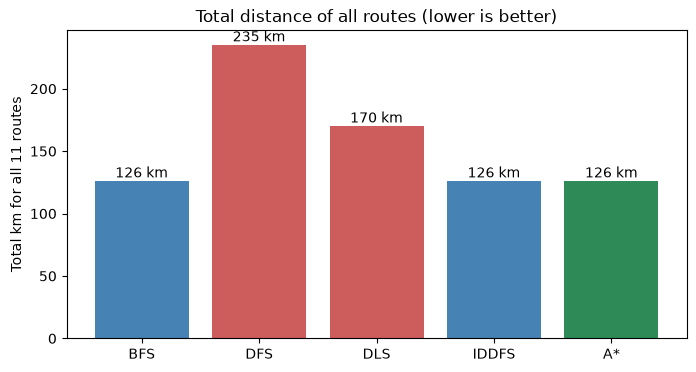

In [10]:
plt.figure(figsize=(8, 4))
bars = plt.bar(algos, [totals[a] for a in algos],
               color=["steelblue", "indianred", "indianred", "steelblue", "seagreen"])
for bar, a in zip(bars, algos):
    plt.text(bar.get_x() + bar.get_width() / 2, totals[a] + 3, f"{totals[a]} km", ha="center")
plt.ylabel("Total km for all 11 routes")
plt.title("Total distance of all routes (lower is better)")
plt.show()

**How to read this comparison**

- Each row is one destination and each column is one algorithm. The number is the length of the route it found, in km. The last column is the shortest distance found by any of them.
- A number with a \* is longer than the shortest route, so that algorithm took a detour.
- BFS, IDDFS and A\* never had a \*: their total is 126 km, which is the shortest possible. DFS added 109 km extra (for example 34 km to Hinjewadi instead of 17 km) and DLS added 44 km extra, because they take the first route they find instead of the shortest.
- BFS and IDDFS are also shortest here only because the route with the fewest roads happens to be the shortest. A\* is the only one of the three that guarantees it.

## Local Search: Patients Inside One Locality

When several patients are in the same locality, one ambulance leaves the locality centre, visits all of them and returns. The visiting order decides the distance. Hill Climbing and a Genetic Algorithm are checked against trying every order (brute force).

In [11]:
def local_dist(a, b):
    """Straight-line km between two incidents inside one locality."""
    (x1, y1), (x2, y2) = incidents[a]["xy"], incidents[b]["xy"]
    return math.hypot(x1 - x2, y1 - y2)


def centre_dist(a):
    x, y = incidents[a]["xy"]
    return math.hypot(x, y)


def locality_tour_length(order):
    """Ambulance leaves the locality centre, visits every incident, returns."""
    if not order:
        return 0.0
    total = centre_dist(order[0]) + centre_dist(order[-1])
    return total + sum(local_dist(order[i], order[i + 1]) for i in range(len(order) - 1))

In [12]:
def hill_climbing(items, length_fn, seed=1):
    """Steepest-ascent hill climbing on the swap neighbourhood."""
    rng = random.Random(seed)
    current = items[:]
    rng.shuffle(current)
    current_len = length_fn(current)
    start_len, steps = current_len, 0
    while True:
        best, best_len = None, current_len
        for i in range(len(current)):
            for j in range(i + 1, len(current)):
                cand = current[:]
                cand[i], cand[j] = cand[j], cand[i]
                cand_len = length_fn(cand)
                if cand_len < best_len - 1e-9:
                    best, best_len = cand, cand_len
        if best is None:                      # local optimum reached
            return current, current_len, start_len, steps
        current, current_len, steps = best, best_len, steps + 1

In [13]:
def genetic_algorithm(items, length_fn, pop_size=60, generations=200,
                      mutation=0.2, elite=2, seed=1):
    rng = random.Random(seed)
    pop = []
    for _ in range(pop_size):
        ind = items[:]
        rng.shuffle(ind)
        pop.append(ind)

    def tournament():
        return min(rng.sample(pop, 3), key=length_fn)

    def order_crossover(p1, p2):
        n = len(p1)
        a, b = sorted(rng.sample(range(n), 2)) if n > 1 else (0, 0)
        child = [None] * n
        child[a:b + 1] = p1[a:b + 1]
        rest = [g for g in p2 if g not in child]
        for k in range(n):
            if child[k] is None:
                child[k] = rest.pop(0)
        return child

    history = []
    for _ in range(generations):
        pop.sort(key=length_fn)
        history.append(length_fn(pop[0]))
        nxt = [p[:] for p in pop[:elite]]
        while len(nxt) < pop_size:
            child = order_crossover(tournament(), tournament())
            if len(child) > 1 and rng.random() < mutation:
                i, j = rng.sample(range(len(child)), 2)
                child[i], child[j] = child[j], child[i]
            nxt.append(child)
        pop = nxt
    pop.sort(key=length_fn)
    return pop[0], length_fn(pop[0]), history


def brute_force(items, length_fn):
    best = min(permutations(items), key=lambda p: length_fn(list(p)))
    return list(best), length_fn(list(best))

In [14]:
print("Length of the visiting tour in km (smaller is better)")
print("'Best' is found by trying every possible order.")
print()
print(f"{'Locality':<12}{'Patients':>9}{'Start':>9}{'HillClimb':>11}{'Genetic':>9}{'Best':>8}")
print("-" * 58)
for loc in ["Kothrud", "Hadapsar", "Pimpri", "Hinjewadi"]:
    items = incidents_in(loc)
    _, hc_len, start_len, _ = hill_climbing(items, locality_tour_length)
    _, ga_len, _ = genetic_algorithm(items, locality_tour_length, 30, 50)
    _, best_len = brute_force(items, locality_tour_length)
    note = "   <- Hill Climbing got stuck" if hc_len > best_len + 0.01 else ""
    print(f"{loc:<12}{len(items):>9}{start_len:>9.2f}{hc_len:>11.2f}{ga_len:>9.2f}{best_len:>8.2f}{note}")

Length of the visiting tour in km (smaller is better)
'Best' is found by trying every possible order.

Locality     Patients    Start  HillClimb  Genetic    Best
----------------------------------------------------------
Kothrud             6    22.53      17.28    16.20   16.20   <- Hill Climbing got stuck
Hadapsar            5    18.50      15.30    15.30   15.30
Pimpri              4    14.68      12.16    12.16   12.16
Hinjewadi           4    12.23       7.09     7.09    7.09


In Kothrud, Hill Climbing stopped at 17.28 km although the best possible tour is 16.20 km, because no single swap could improve it any further. The Genetic Algorithm reached 16.20 km. In the other three localities both methods found the best tour.

## Local Search: Patrol Tour of All 28 Incidents

One ambulance leaves the hospital, visits all 28 incidents and returns (straight-line distances). Trying every order is impossible here.

In [15]:
def plane_xy(name_or_id):
    lat0, lon0 = coordinates[HOSPITAL]
    if name_or_id in incidents:
        loc = incidents[name_or_id]["locality"]
        dx, dy = incidents[name_or_id]["xy"]
    else:
        loc, dx, dy = name_or_id, 0, 0
    lat, lon = coordinates[loc]
    return ((lon - lon0) * 105.6 + dx, (lat - lat0) * 111.0 + dy)


def patrol_tour_length(order):
    pts = [plane_xy(HOSPITAL)] + [plane_xy(i) for i in order] + [plane_xy(HOSPITAL)]
    return sum(math.dist(pts[i], pts[i + 1]) for i in range(len(pts) - 1))

all_ids = list(incidents)
_, hc_len, start_len, _ = hill_climbing(all_ids, patrol_tour_length)
_, ga_len, _ = genetic_algorithm(all_ids, patrol_tour_length, 150, 400)

print(f"Random order: {start_len:.1f} km")
print(f"Hill Climbing: {hc_len:.1f} km")
print(f"Genetic Algorithm: {ga_len:.1f} km")
print(f"Genetic Algorithm saves {hc_len - ga_len:.1f} km over Hill Climbing ({100 * (hc_len - ga_len) / hc_len:.0f}% shorter)")

Random order: 303.7 km
Hill Climbing: 149.7 km
Genetic Algorithm: 100.9 km
Genetic Algorithm saves 48.8 km over Hill Climbing (33% shorter)


## Constraint Satisfaction Problem (CSP)

Six ambulances are based around the city (ALS is an advanced life support unit, BLS a basic one). Eight emergency calls have to be assigned to them.

- Variables: the 8 calls.
- Domain: the ambulances A1 to A6.
- A Critical call must go to an ALS ambulance.
- The ambulance base must be within 14 km of the call by road.
- One ambulance takes at most 2 calls, and never two Critical calls.
- The total base-to-call distance of one ambulance must be at most 22 km.

The solver is backtracking with the MRV rule, which picks the call with the fewest legal ambulances first.

In [16]:
ambulances = {
    "A1": {"base": "Shivajinagar", "type": "ALS"},
    "A2": {"base": "Kothrud", "type": "BLS"},
    "A3": {"base": "Swargate", "type": "ALS"},
    "A4": {"base": "Hadapsar", "type": "BLS"},
    "A5": {"base": "Hinjewadi", "type": "BLS"},
    "A6": {"base": "Viman Nagar", "type": "ALS"},
}


CSP_INCIDENTS = ["E001", "E007", "E012", "E016", "E019", "E021", "E023", "E025"]


MAX_RADIUS = 14


MAX_SHIFT_KM = 22


CSP_INFEASIBLE = CSP_INCIDENTS[:-1] + ["E026"]

_base_dist = {a: dijkstra(d["base"]) for a, d in ambulances.items()}


def csp_domains(variables=None):
    """Unary constraints: ALS for Critical cases, and response radius."""
    domains = {}
    for e in (variables or CSP_INCIDENTS):
        loc, sev = incidents[e]["locality"], incidents[e]["severity"]
        domains[e] = [a for a, d in ambulances.items()
                      if _base_dist[a][loc] <= MAX_RADIUS
                      and (sev != "Critical" or d["type"] == "ALS")]
    return domains


def consistent(var, amb, assignment, capacity):
    """Binary/global constraints between var=amb and current assignment."""
    mine = [v for v, a in assignment.items() if a == amb]
    if len(mine) + 1 > capacity:
        return False
    if incidents[var]["severity"] == "Critical" and any(
            incidents[v]["severity"] == "Critical" for v in mine):
        return False
    km = sum(_base_dist[amb][incidents[v]["locality"]] for v in mine + [var])
    return km <= MAX_SHIFT_KM


def solve_csp(capacity=2, use_mrv=True, variables=None):
    variables = variables or CSP_INCIDENTS
    domains = csp_domains(variables)
    stats = {"nodes": 0}

    def legal(var, assignment):
        vals = [a for a in domains[var] if consistent(var, a, assignment, capacity)]
        return sorted(vals, key=lambda a: _base_dist[a][incidents[var]["locality"]])

    def backtrack(assignment):
        stats["nodes"] += 1
        if len(assignment) == len(variables):
            return assignment
        todo = [v for v in variables if v not in assignment]
        if use_mrv:                            # fewest remaining legal values first
            var = min(todo, key=lambda v: len(legal(v, assignment)))
        else:
            var = todo[0]
        for amb in legal(var, assignment):
            assignment[var] = amb
            result = backtrack(assignment)
            if result:
                return result
            del assignment[var]
        return None

    solution = backtrack({})
    return solution, stats["nodes"], domains


def assignment_cost(solution):
    return sum(_base_dist[a][incidents[e]["locality"]] for e, a in solution.items())

In [17]:
solution, nodes, domains = solve_csp()

for e in CSP_INCIDENTS:
    loc, sev = incidents[e]["locality"], incidents[e]["severity"]
    print(f"{e} ({loc}, {sev}) -> {solution[e]}, {_base_dist[solution[e]][loc]} km from its base")

print("Total base-to-call distance:", assignment_cost(solution), "km")
print()
print("Capacity of 1 call per ambulance:", "no solution" if solve_csp(capacity=1)[0] is None else "solution found")
print("4 Critical calls, 3 ALS ambulances:", "no solution" if solve_csp(variables=CSP_INFEASIBLE)[0] is None else "solution found")

E001 (Kothrud, Critical) -> A1, 6 km from its base
E007 (Hadapsar, Critical) -> A6, 9 km from its base
E012 (Pimpri, Minor) -> A1, 14 km from its base
E016 (Hinjewadi, Minor) -> A5, 0 km from its base
E019 (Hinjewadi, Minor) -> A5, 0 km from its base
E021 (Swargate, Serious) -> A3, 0 km from its base
E023 (Baner, Critical) -> A3, 14 km from its base
E025 (Kharadi, Serious) -> A6, 5 km from its base
Total base-to-call distance: 48 km

Capacity of 1 call per ambulance: no solution
4 Critical calls, 3 ALS ambulances: no solution


## Result

For finding routes, A\* gave the shortest distance for every locality (126 km in total), with BFS and IDDFS equal to it on this network, while DFS and DLS were longer (235 km and 170 km). For ordering patients, the Genetic Algorithm was better than or equal to Hill Climbing every time, and on the 28-incident tour it gave 100.9 km against 149.7 km. The CSP produced an allocation that obeys all the rules, with a total of 48 km from bases to calls.

## Conclusion

A\* is the right choice for the shortest route because BFS and DFS ignore road length. Hill Climbing is quick for a few patients but can get stuck, while the Genetic Algorithm gives shorter tours when there are many stops. The CSP makes sure that equipment, distance, capacity and shift rules are all followed, and it shows clearly when a situation cannot be solved with the ambulances available.